<a href="https://colab.research.google.com/github/TetianaMartynovska1/AisleGuide-app/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
sample(1:10, 5, replace = TRUE)

[1] 4 6 7 7 6

In [ ]:
n <- 10 # Generate 10 numbers
ceiling(runif(n, 0, 10))

[1] 1 8 7 9 9 3 5 7 4 9

In [ ]:
floor(runif(n, 1, 11))

[1] 5 7 9 4 9 5 1 5 3 1

In [ ]:
round(runif(n, 0.5, 10.5))

[1]  5  5  3  9  8  5 10  9  3 10

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


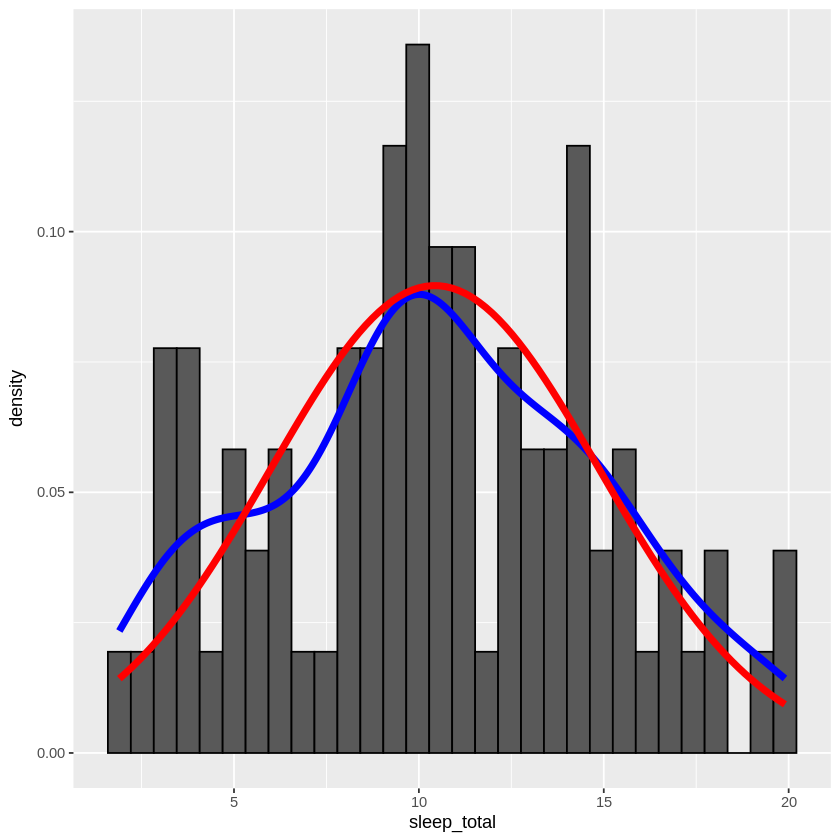

In [ ]:
library(ggplot2)
ggplot(msleep, aes(x = sleep_total)) +
      geom_histogram(colour = "black", aes(y = ..density..)) +
      geom_density(colour = "blue", size = 2) +
      geom_function(fun = dnorm, colour = "red", size = 2,
                    args = list(mean = mean(msleep$sleep_total),
                                  sd = sd(msleep$sleep_total)))

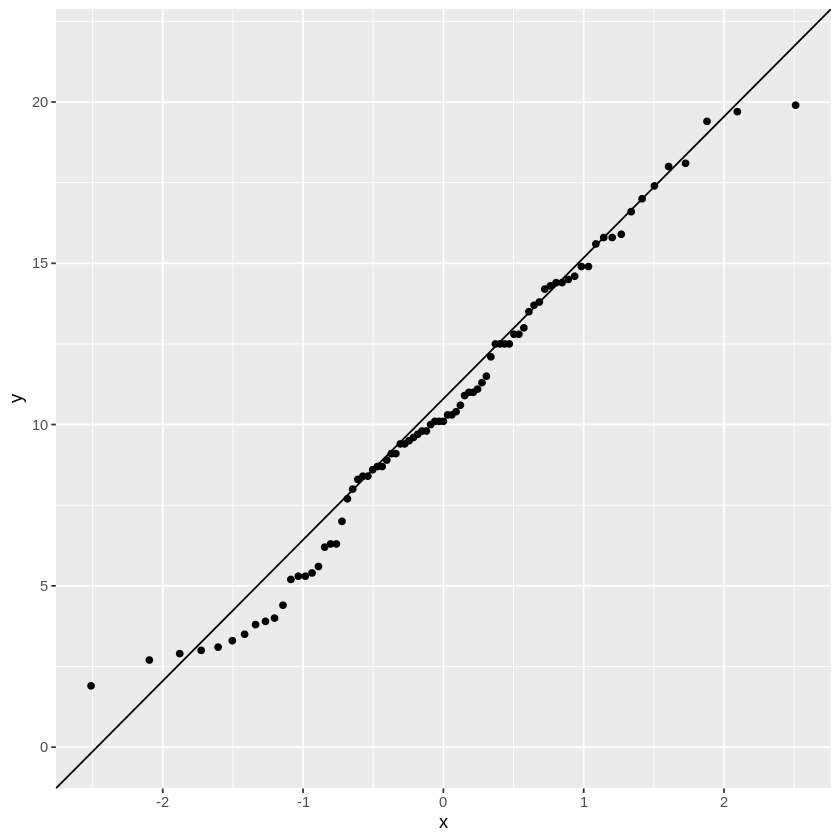

In [ ]:
ggplot(msleep, aes(sample = sleep_total)) +
        geom_qq() + geom_qq_line()

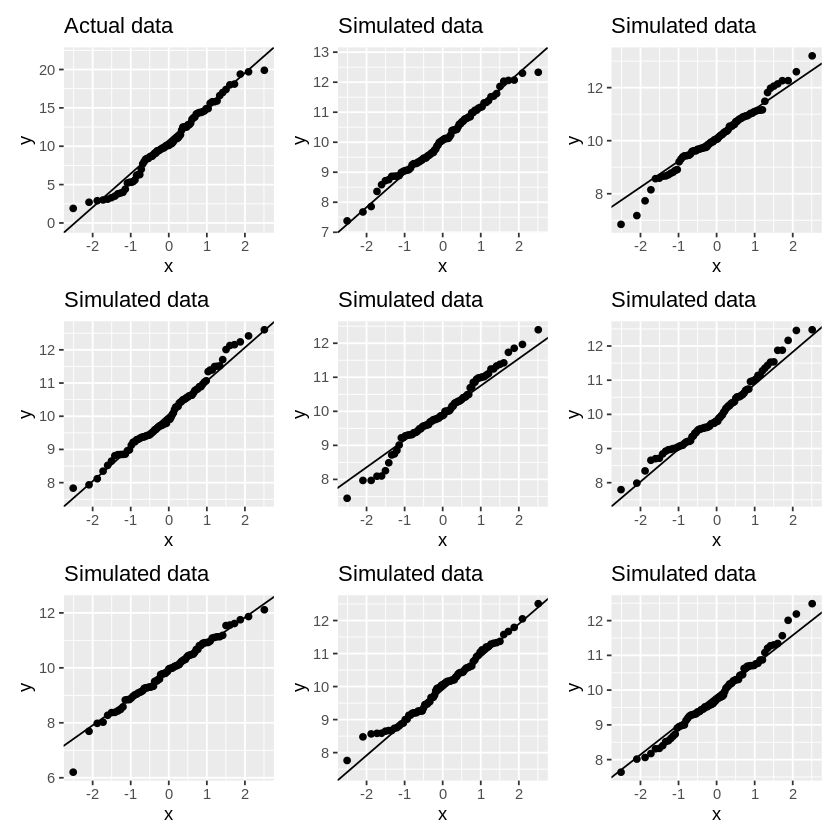

In [ ]:
# Create a Q-Q-plot for the total sleep data, and store
# it in a list:
qqplots <- list(ggplot(msleep, aes(sample = sleep_total)) +
  geom_qq() + geom_qq_line() + ggtitle("Actual data"))

# Compute the sample size n:
n <- sum(!is.na(msleep$sleep_total))

# Generate 8 new datasets of size n from a normal distribution.
# Then draw Q-Q-plots for these and store them in the list:
for(i in 2:9)
{
    generated_data <- data.frame(normal_data = rnorm(n, 10, 1))
    qqplots[[i]] <- ggplot(generated_data, aes(sample = normal_data)) +
      geom_qq() + geom_qq_line() + ggtitle("Simulated data")
}

# Plot the resulting Q-Q-plots side-by-side:
library(patchwork)
(qqplots[[1]] + qqplots[[2]] + qqplots[[3]]) /
  (qqplots[[4]] + qqplots[[5]] + qqplots[[6]]) /
  (qqplots[[7]] + qqplots[[8]] + qqplots[[9]])

In [ ]:
install.packages("patchwork", repos = "https://cloud.r-project.org/")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


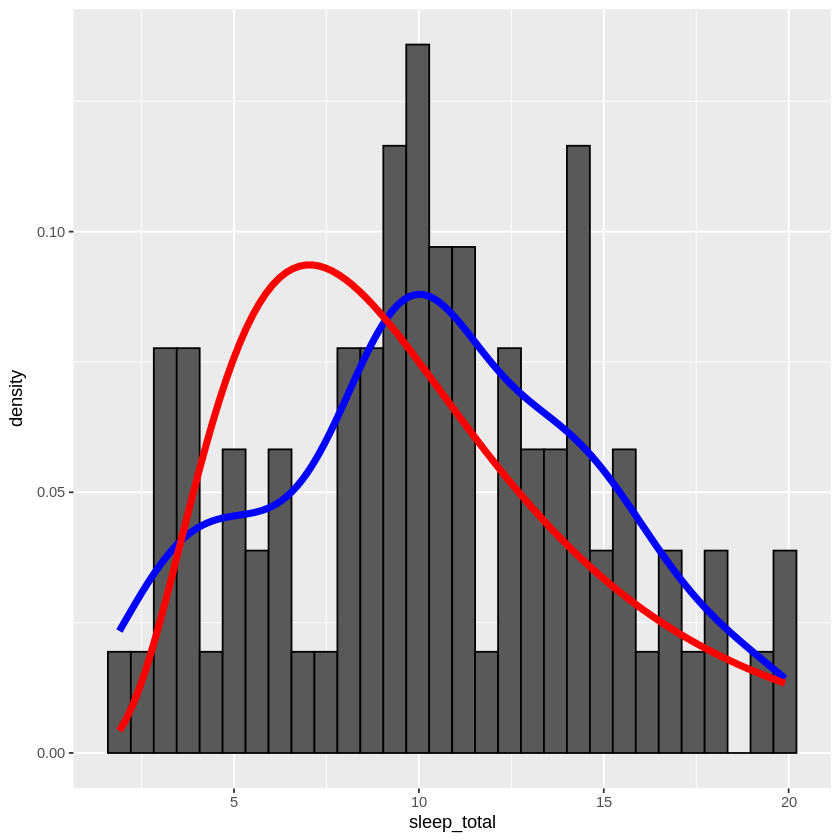

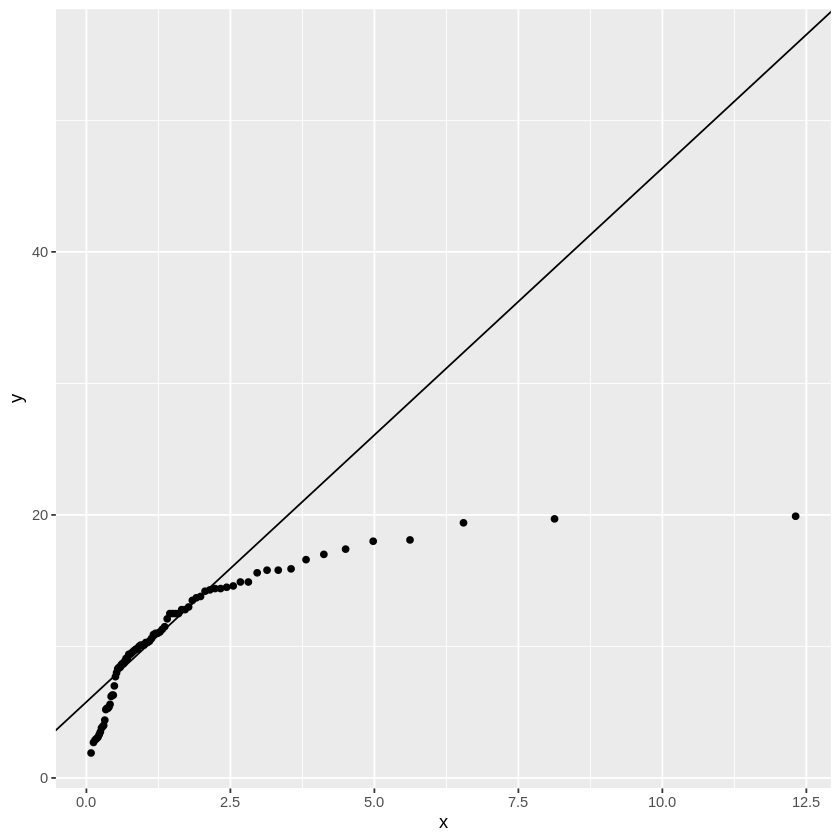

In [ ]:
# Histogram:
ggplot(msleep, aes(x = sleep_total)) +
      geom_histogram(colour = "black", aes(y = ..density..)) +
      geom_density(colour = "blue", size = 2) +
      geom_function(fun = dlnorm, colour = "red", size = 2,
                  args = list(meanlog = mean(log(msleep$sleep_total)),
                              sdlog = sd(log(msleep$sleep_total))))

# Q-Q plot:
ggplot(msleep, aes(sample = sleep_total)) +
        geom_qq(distribution = qlnorm) +
        geom_qq_line(distribution = qlnorm)

In [ ]:
library(ggplot2)
shapiro.test(msleep$sleep_total)


	Shapiro-Wilk normality test

data:  msleep$sleep_total
W = 0.97973, p-value = 0.2143


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


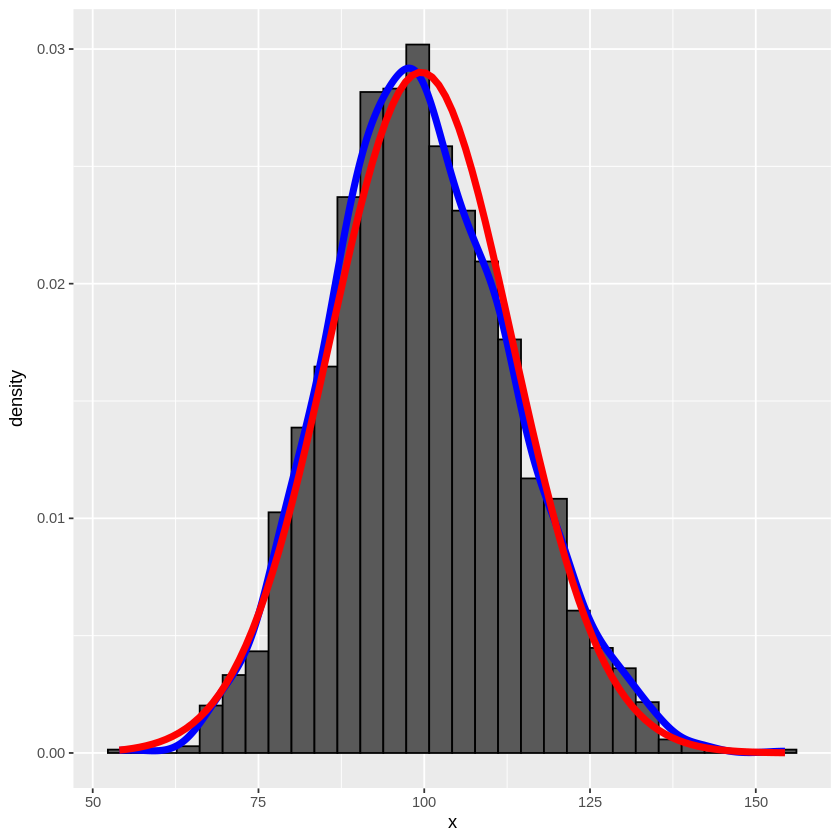

In [ ]:
generated_data <- data.frame(x = rchisq(2000, 100))

ggplot(generated_data, aes(x)) +
      geom_histogram(colour = "black", aes(y = ..density..)) +
      geom_density(colour = "blue", size = 2) +
      geom_function(fun = dnorm, colour = "red", size = 2,
                    args = list(mean = mean(generated_data$x),
                                  sd = sd(generated_data$x)))

In [ ]:
shapiro.test(generated_data$x)


	Shapiro-Wilk normality test

data:  generated_data$x
W = 0.99656, p-value = 0.0001748


In [ ]:
# Function for our custom estimator:
max_min_avg <- function(x)
{
      return((max(x)+min(x))/2)
}

# Function for simulation:
simulate_estimators <- function(n, mu = 0, sigma = 1, B = 1e4)
{
    cat(n, "\n")
    res <- data.frame(x_mean = vector("numeric", B),
                      x_median = vector("numeric", B),
                      x_mma = vector("numeric", B))

    # Start progress bar:
    pbar <- txtProgressBar(min = 0, max = B, style = 3)

    for(i in seq_along(res$x_mean))
    {
          x <- rnorm(n, mu, sigma)
          res$x_mean[i] <- mean(x)
          res$x_median[i] <- median(x)
          res$x_mma[i] <- max_min_avg(x)

          # Update progress bar
          setTxtProgressBar(pbar, i)
    }
    close(pbar)

    # Return a list containing the sample size,
    # and the simulation results:
    return(list(n = n,
                bias = colMeans(res-mu),
                vars = apply(res, 2, var)))
}

In [ ]:
# Create a vector of samples sizes:
n_vector <- seq(10, 100, 10)

# Run a simulation for each value in n_vector:

# Using base R:
res <- apply(data.frame(n = n_vector), 1, simulate_estimators)

# Using purrr:
library(purrr)
res <- map(n_vector, simulate_estimators)

10 
  |======================================================================| 100%
20 
  |======================================================================| 100%
30 
  |======================================================================| 100%
40 
  |======================================================================| 100%
50 
  |======================================================================| 100%
60 
  |======================================================================| 100%
70 
  |======================================================================| 100%
80 
  |======================================================================| 100%
90 
  |======================================================================| 100%
100 
  |======================================================================| 100%
10 
  |======================================================================| 100%
20 
  |====================================================================

In [ ]:
# Create a vector of samples sizes:
n_vector <- seq(10, 100, 10)

# Run a simulation for each value in n_vector:

# Using base R:
res <- apply(data.frame(n = n_vector), 1, simulate_estimators)

# Using purrr:
library(purrr)
res <- map(n_vector, simulate_estimators)

10 
  |======================================================================| 100%
20 
  |======================================================================| 100%
30 
  |======================================================================| 100%
40 
  |======================================================================| 100%
50 
  |======================================================================| 100%
60 
  |======================================================================| 100%
70 
  |======================================================================| 100%
80 
  |======================================================================| 100%
90 
  |======================================================================| 100%
100 
  |======================================================================| 100%
10 
  |======================================================================| 100%
20 
  |====================================================================

In [ ]:
simres <- matrix(unlist(res), 10, 7, byrow = TRUE)
simres <- data.frame(simres)
names(simres) <- names(unlist(res))[1:7]
simres

n,bias.x_mean,bias.x_median,bias.x_mma,vars.x_mean,vars.x_median,vars.x_mma
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,-0.0001759948,0.0013519164,-0.0048601564,0.10108883,0.13766782,0.18828446
20,0.0045508830,0.0057516138,0.0030996397,0.04915869,0.07212878,0.14267997
30,0.0036864140,0.0046425781,-0.0007455163,0.03328818,0.04918054,0.12729693
40,0.0007346503,-0.0005740616,0.0037831115,0.02492697,0.03848534,0.11613770
50,-0.0010571577,-0.0029553486,0.0030827164,0.01987351,0.03078829,0.10668726
60,0.0003006078,-0.0014472381,0.0013465455,0.01657426,0.02539377,0.10568961
70,0.0017293473,0.0010724951,0.0021300825,0.01457612,0.02264189,0.10056010
80,0.0004496851,0.0002594276,-0.0017434499,0.01208419,0.01899101,0.09804663
90,0.0007702707,0.0007483432,-0.0021519809,0.01114679,0.01720801,0.09521507


In [ ]:
library(data.table)

simres <- as.data.table(simres)

simres2 <- melt(simres, id.vars = "n", measure.vars = 2:7)

simres2[, c("measure", "estimator") := tstrsplit(variable, ".", fixed = TRUE)]


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following object is masked from ‘package:base’:

    %notin%




In [ ]:
library(tidyr)
simres |> pivot_longer(names(simres)[2:7],
                   names_to = "variable",
                   values_to = "value") |>
        separate(variable,
                into = c("measure", "estimator"),
                sep = "[.]") -> simres2

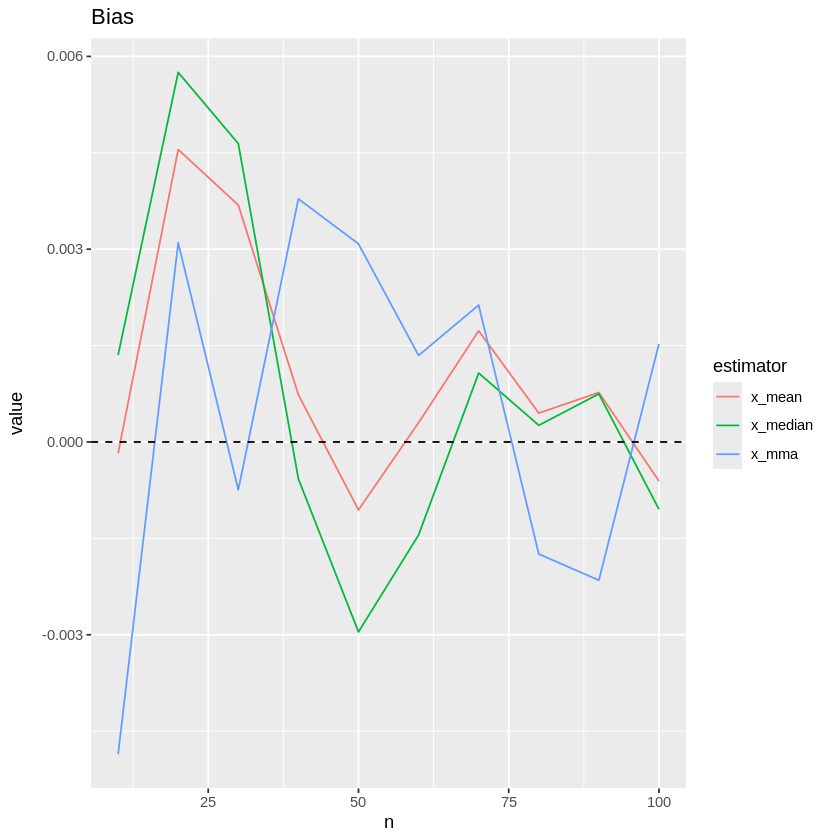

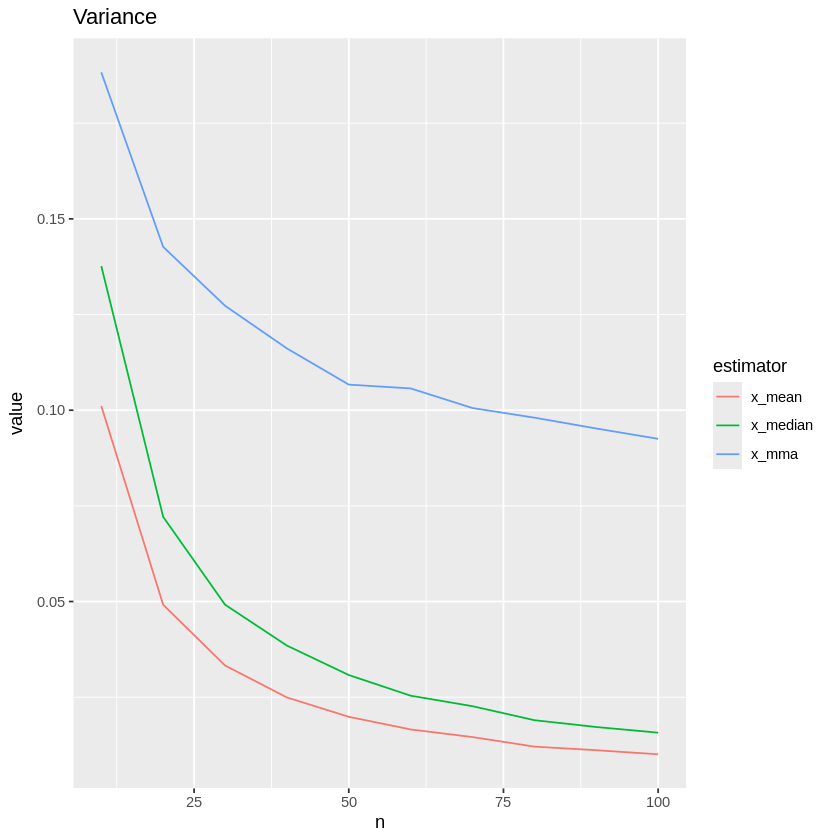

In [ ]:
library(ggplot2)
# Plot the bias, with a reference line at 0:
ggplot(subset(simres2, measure == "bias"), aes(n, value,
                                               col = estimator)) +
      geom_line() +
      geom_hline(yintercept = 0, linetype = "dashed") +
      ggtitle("Bias")

# Plot the variance:
ggplot(subset(simres2, measure == "vars"), aes(n, value,
                                               col = estimator)) +
      geom_line() +
      ggtitle("Variance")

In [ ]:
# Function for our custom estimator:
max_min_avg <- function(x)
{
      return((max(x)+min(x))/2)
}

# Function for simulation:
simulate_estimators <- function(n, df = 3, B = 1e4)
{
    cat(n, "\n")
    res <- data.frame(x_mean = vector("double", B),
                      x_median = vector("double", B),
                      x_mma = vector("double", B))

    # Start progress bar:
    pbar <- txtProgressBar(min = 0, max = B, style = 3)

    for(i in seq_along(res$x_mean))
    {
          x <- rt(n, df)
          res$x_mean[i] <- mean(x)
          res$x_median[i] <- median(x)
          res$x_mma[i] <- max_min_avg(x)

          # Update progress bar
          setTxtProgressBar(pbar, i)
    }
    close(pbar)

    # Return a list containing the sample size,
    # and the simulation results:
    return(list(n = n,
                bias = colMeans(res-0),
                vars = apply(res, 2, var)))
}

10 
  |======================================================================| 100%
20 
  |======================================================================| 100%
30 
  |======================================================================| 100%
40 
  |======================================================================| 100%
50 
  |======================================================================| 100%
60 
  |======================================================================| 100%
70 
  |======================================================================| 100%
80 
  |======================================================================| 100%
90 
  |======================================================================| 100%
100 
  |======================================================================| 100%


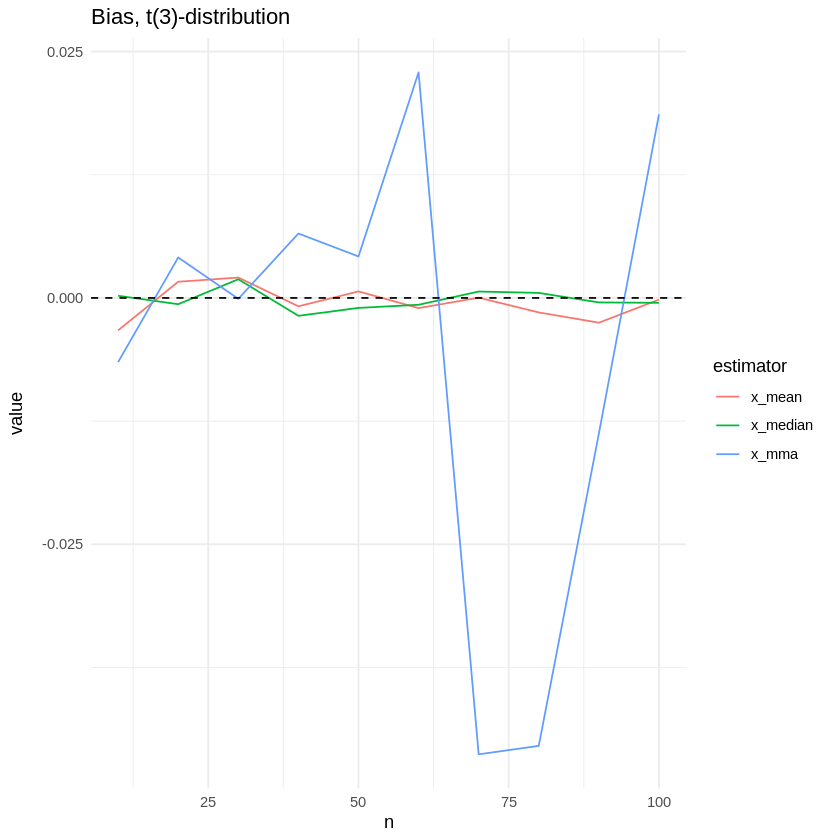

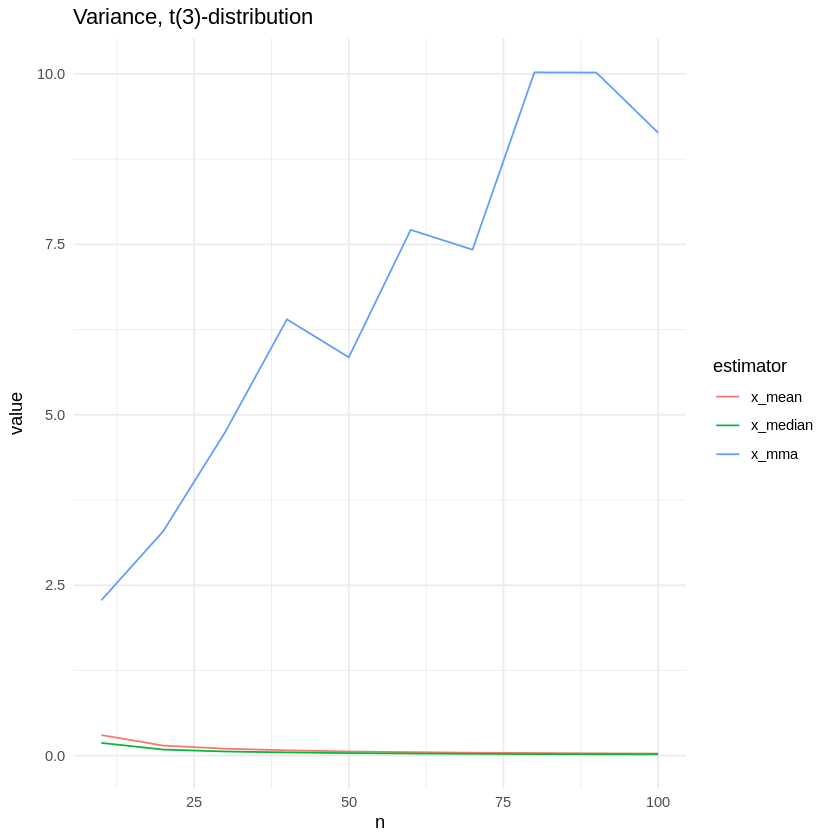

In [ ]:
library(data.table)
library(ggplot2)

# =========================
# 1. Вектор розмірів вибірки
# =========================
n_vector <- seq(10, 100, 10)

# =========================
# 2. Симуляція
# =========================
res <- lapply(n_vector, simulate_estimators)

# =========================
# 3. РОЗГОРТАННЯ РЕЗУЛЬТАТІВ (ВАЖЛИВО: без list)
# =========================
simres <- do.call(rbind, lapply(seq_along(res), function(i) {
  c(n = n_vector[i], unlist(res[[i]]))
}))

simres <- as.data.frame(simres)

# =========================
# 4. Переводимо ВСЕ в numeric (критично для ggplot)
# =========================
simres[] <- lapply(simres, as.numeric)

# =========================
# 5. Переводимо в data.table
# =========================
simres <- as.data.table(simres)

# =========================
# 6. long format (tidy)
# =========================
simres2 <- melt(
  simres,
  id.vars = "n"
)

# =========================
# 7. Розділяємо назви змінних
# =========================
simres2[, c("measure", "estimator") :=
          tstrsplit(variable, ".", fixed = TRUE)]

# =========================
# 8. ГРАФІК: BIAS
# =========================
ggplot(simres2[measure == "bias"],
       aes(x = n, y = value, color = estimator)) +
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  ggtitle("Bias, t(3)-distribution") +
  theme_minimal()

# =========================
# 9. ГРАФІК: VARIANCE
# =========================
ggplot(simres2[measure == "vars"],
       aes(x = n, y = value, color = estimator)) +
  geom_line() +
  ggtitle("Variance, t(3)-distribution") +
  theme_minimal()

In [ ]:
install.packages("reshape2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
simulate_type_I <- function(n1, n2, dist, B = 9999, df = 3) {

  p_values <- replicate(B, {
    x <- dist(n1, df)
    y <- dist(n2, df)

    t.test(x, y)$p.value
  })

  mean(p_values < 0.05)
}

In [ ]:
simulate_type_I(20, 20, rt, B = 9999, df = 3)
simulate_type_I(20, 30, rt, B = 9999, df = 3)

[1] 0.04680468

[1] 0.04460446

In [ ]:
B <- 9999
binomDiffCI(B*0.04810481, B*0.04340434, B, B, method = "wilson")

lower        upper 
-0.001091317  0.010492257

In [ ]:
binomDiffCI <- function(x1, x2, n1, n2, method = "wilson") {

  p1 <- x1 / n1
  p2 <- x2 / n2

  diff <- p1 - p2

  se <- sqrt(p1*(1 - p1)/n1 + p2*(1 - p2)/n2)

  z <- 1.96

  lower <- diff - z * se
  upper <- diff + z * se

  c(lower = lower, upper = upper)
}

In [ ]:
# Balanced sample sizes:
simulate_power(20, 20, function(n) { rt(n, df = 3,) },
                       function(n) { rt(n, df = 3) + 1 },
                       B = 9999)

# Imbalanced sample sizes:
simulate_power(20, 30, function(n) { rt(n, df = 3,) },
                       function(n) { rt(n, df = 3) + 1 },
                       B = 9999)

ERROR: Error in dist_fun(n1, df): unused argument (df)


In [ ]:
simulate_power <- function(n1, n2, dist_fun, B = 1000, delta = 1, df = 3, alpha = 0.05) {

  rejections <- replicate(B, {
    x <- dist_fun(n1, df)
    y <- dist_fun(n2, df) + delta

    t.test(x, y)$p.value < alpha
  })

  mean(rejections)
}

In [ ]:
power.cor.test(n_start = 10, rho = 0.5, power = 0.9,
               method = "spearman")
power.cor.test(n_start = 10, rho = 0.2, power = 0.8,
               method = "spearman")

ERROR: Error in power.cor.test(n_start = 10, rho = 0.5, power = 0.9, method = "spearman"): could not find function "power.cor.test"


In [ ]:
power.cor.test <- function(n_start = 10, rho = 0.5,
                           power_target = 0.8,
                           method = "spearman",
                           B = 5000, alpha = 0.05) {

  n <- n_start

  repeat {

    p_vals <- replicate(B, {

      x <- rnorm(n)
      y <- rho * x + sqrt(1 - rho^2) * rnorm(n)

      cor.test(x, y, method = method)$p.value
    })

    pow <- mean(p_vals < alpha)

    if (pow >= power_target) break

    n <- n + 1
  }

  return(list(n_required = n, power = pow))
}

In [ ]:
cp_width <- function(n, p, level = 0.05, B = 999)
{
      widths <- rep(NA, B)

      # Start progress bar:
      pbar <- txtProgressBar(min = 0, max = B, style = 3)

      for(i in 1:B)
      {
            # Generate binomial data:
            x <- rbinom(1, n, p)

            # Compute interval width:
            interval <- binomCI(x, n, conf.level = 0.95,
                                method = "clopper-pearson")$conf.int
            widths[i] <- interval[2] - interval[1]

            # Update progress bar:
            setTxtProgressBar(pbar, i)
      }

      close(pbar)

      return(mean(widths))
}

In [ ]:
cp_ssize <- function(n_start = 10, p, n_incr = 5, level = 0.05,
                     width = 0.1, B = 999)
{
    # Set initial values
    n <- n_start
    width_now <- 1

    # Check power for different sample sizes:
    while(width_now > width)
    {
        width_now <- cp_width(n, p, level, B)
        cat("n =", n, " - Width:", width_now, "\n")
        n <- n + n_incr
    }

    # Return the result:
    cat("\nWhen n =", n, "the expected with is", round(width, 3), "\n")
    return(n)
}

In [ ]:
cp_ssize <- function(n_start, p, n_incr = 1,
                     level = 0.05, width = 0.01, B = 1000) {

  n <- n_start

  repeat {

    cover <- replicate(B, {

      x <- rbinom(1, n, p)

      ci <- binom.test(x, n, conf.level = 1 - level)$conf.int

      (ci[2] - ci[1]) <= width
    })

    if (mean(cover) >= 0.95) break

    n <- n + n_incr
  }

  return(n)
}

In [ ]:
library(ggplot2)
boot_data <- na.omit(subset(msleep,
                  vore == "carni" | vore == "herbi")[,c("sleep_total",
                                                          "vore")])
# Compute group means and sizes:
group_means <- aggregate(sleep_total ~ vore,
                         data = boot_data, FUN = mean)
group_sizes <- aggregate(sleep_total ~ vore,
                         data = boot_data, FUN = length)
n1 <- group_sizes[1, 2]

# Create a centred dataset, where both groups have mean 0:
boot_data$sleep_total[boot_data$vore == "carni"] <-
     boot_data$sleep_total[boot_data$vore == "carni"] -
                                      group_means[1, 2]
boot_data$sleep_total[boot_data$vore == "herbi"] <-
     boot_data$sleep_total[boot_data$vore == "herbi"] -
                                      group_means[2, 2]

# Verify that we've centred the two groups:
aggregate(sleep_total ~ vore, data = boot_data, FUN = mean)

# First, we resample from the centred data sets. Then we label
# some observations as carnivores, and add the group mean for
# carnivores to them, and label some as herbivores and add
# that group mean instead. That way both groups are used to
# estimate the variability of the observations.
mean_diff_msleep <- function(data, i)
{
    # Create a sample with the same mean as the carnivore group:
    sample1 <- data[i[1:n1], 1] + group_means[1, 2]
    # Create a sample with the same mean as the herbivore group:
    sample2 <- data[i[(n1+1):length(i)], 1] + group_means[2, 2]
    # Compute the difference in means:
    return(mean(sample1$sleep_total) - mean(sample2$sleep_total))
}

library(boot)

# Do the resampling:
boot_res <- boot(boot_data,
                 mean_diff_msleep,
                 9999)

# Compute confidence intervals:
boot.ci(boot_res, type = c("perc", "bca"))

vore,sleep_total
<chr>,<dbl>
carni,4.675565e-16
herbi,-1.665335e-16


Warning message in norm.inter(t, adj.alpha):
“extreme order statistics used as endpoints”


BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 9999 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_res, type = c("perc", "bca"))

Intervals : 
Level     Percentile            BCa          
95%   (-1.808,  3.523 )   (-4.762, -1.069 )  
Calculations and Intervals on Original Scale
Some BCa intervals may be unstable

In [ ]:
boot_pval <- function(x, y, B = 1000) {

  obs <- t.test(x, y)$statistic

  pooled <- c(x, y)
  n1 <- length(x)

  boot_stats <- replicate(B, {
    sample1 <- sample(pooled, n1, replace = TRUE)
    sample2 <- sample(pooled, length(pooled) - n1, replace = TRUE)

    t.test(sample1, sample2)$statistic
  })

  mean(abs(boot_stats) >= abs(obs))
}

In [ ]:
# The null hypothesis is there the difference is 0:
diff_null <- 0

# Set initial conditions:
in_interval <- TRUE
alpha <- 0

# Find the lowest alpha for which diff_null is in the
# interval:
while(in_interval)
{
    alpha <- alpha + 0.001
    interval <- boot.ci(boot_res,
                        conf = 1 - alpha,
                        type = "perc")$percent[4:5]
    in_interval <- diff_null > interval[1] & diff_null < interval[2]
}

# Print the p-value:
alpha

[1] 0.515